# Language Models for Text Classification with the AG News Dataset — Student Version

In this notebook, you will progressively build a small prompting-based text classification pipeline with the **AG News** dataset.

## Learning goals
- load and inspect a text classification dataset
- design **zero-shot** and **few-shot** prompts
- query **two LLM APIs** (**Groq** and **Mistral**)
- normalize model outputs
- evaluate predictions on a small test subset
- reflect on strengths and limitations of prompting for classification


## 1. Setup

This notebook should use:
- `datasets` for AG News
- `pandas` and `matplotlib` for quick inspection
- `groq` for one API
- `mistralai` for a second API

> Keep API keys out of the notebook when possible.

In [ ]:
#!pip install -q datasets pandas matplotlib groq

In [3]:
import os
import re
import json
import random
import time
from typing import List, Dict, Optional

import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from groq import Groq

from mistralai import Mistral


In [ ]:
SEED = 42

# Set the random seed
random.seed(SEED)

# Small subsets keep the demo fast and avoid exhausting free quotas.
TRAIN_SUBSET = 24
TEST_SUBSET = 20

LABELS = {
    0: "World",
    1: "Sports",
    2: "Business",
    3: "Sci/Tech",
}

# Read API keys from environment variables
GROQ_API_KEY = "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"

print("GROQ_API_KEY set:", GROQ_API_KEY is not None)

# Quick check


GROQ_MODEL = "llama-3.3-70b-versatile"

MISTRAL_MODEL = "mistral-large-latest"


GROQ_API_KEY set: True


## 2. Load and inspect AG News

AG News contains four topic classes:
1. World
2. Sports
3. Business
4. Sci/Tech

Each example contains a piece of text and a numeric label.

In [6]:
print("Loading AG News...")
dataset = load_dataset("ag_news")

train_data = dataset["train"].shuffle(seed=SEED)
test_data = dataset["test"].shuffle(seed=SEED)

if TRAIN_SUBSET is not None:
    train_data = train_data.select(range(TRAIN_SUBSET))
if TEST_SUBSET is not None:
    test_data = test_data.select(range(TEST_SUBSET))

print(dataset)
print("Train subset size:", len(train_data))
print("Test subset size:", len(test_data))

Loading AG News...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})
Train subset size: 24
Test subset size: 20


In [7]:
# Convert the subsets to pandas DataFrames
df_train = train_data.to_pandas()
df_test = test_data.to_pandas()

# Map numeric labels to label names
df_train["label_name"] = df_train["label"].map(LABELS)
df_test["label_name"] = df_test["label"].map(LABELS)

# Inspect a few rows
display(df_train.head())
display(df_test.head())

,text,label,label_name
0,Bangladesh paralysed by strikes Opposition act...,0,World
1,Desiring Stability Redskins coach Joe Gibbs ex...,1,Sports
2,Will Putin #39;s Power Play Make Russia Safer?...,0,World
3,U2 pitches for Apple New iTunes ads airing dur...,3,Sci/Tech
4,S African TV in beheading blunder Public broad...,0,World


,text,label,label_name
0,Indian board plans own telecast of Australia s...,1,Sports
1,Stocks Higher on Drop in Jobless Claims A shar...,2,Business
2,"Nuggets 112, Raptors 106 Carmelo Anthony score...",1,Sports
3,Stocks Higher on Drop in Jobless Claims A shar...,2,Business
4,REVIEW: 'Half-Life 2' a Tech Masterpiece (AP) ...,3,Sci/Tech


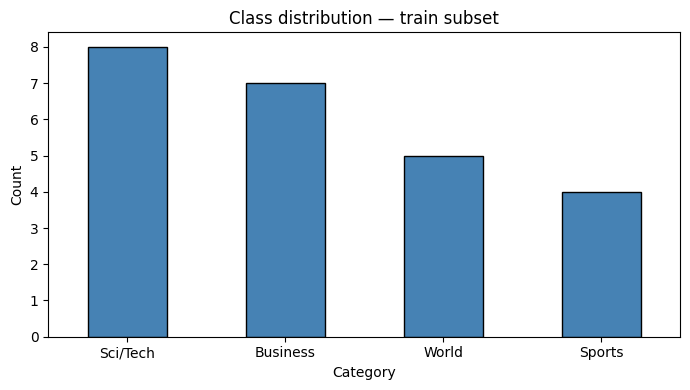

In [8]:
# Plot the class distribution in the train subset
label_counts = df_train["label_name"].value_counts()

plt.figure(figsize=(7, 4))
label_counts.plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Class distribution — train subset")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3. Build prompts

We want the model to return **only one** of these labels:
- `World`
- `Sports`
- `Business`
- `Sci/Tech`


In [9]:
def format_example(example):
    """
    Return a formatted string version of one AG News example.
    Includes the full text (which already contains a title-like beginning).
    """
    return f"Text: {example['text'].strip()}"

In [10]:
def build_zero_shot_prompt(example):
    """
    Zero-shot prompt: instructions only, no labeled examples.
    """
    prompt = f"""You are a news article classifier.
Classify the following news article into exactly one of these categories:
World, Sports, Business, Sci/Tech

Rules:
- Reply with ONLY the category name, nothing else.
- Do not add punctuation, explanations, or extra words.

{format_example(example)}

Category:"""
    return prompt.strip()

In [11]:
def build_few_shot_prompt(example, support_examples):
    """
    Few-shot prompt: same instructions + labeled support examples before the target.
    """
    support_block = ""

    for sup in support_examples:
        label_name = LABELS[sup["label"]]
        support_block += f"{format_example(sup)}\nCategory: {label_name}\n\n"

    prompt = f"""You are a news article classifier.
Classify the following news article into exactly one of these categories:
World, Sports, Business, Sci/Tech

Rules:
- Reply with ONLY the category name, nothing else.
- Do not add punctuation, explanations, or extra words.

Here are some examples:

{support_block.strip()}

Now classify the following article:

{format_example(example)}

Category:"""
    return prompt.strip()

## 4. API helpers

We will compare:
1. **Groq**
2. **Mistral**

Both functions should receive a prompt and return the model's raw text output.

In [12]:
# Initialize the Groq client
groq_client = Groq(api_key=GROQ_API_KEY)

def ask_groq(prompt, model=GROQ_MODEL):
    """
    Send a prompt to Groq and return the raw text response.
    """
    response = groq_client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        temperature=0,
        max_tokens=10,
    )
    return response.choices[0].message.content

In [ ]:
# Initialize the Mistral client
mistral_client = Mistral(api_key=MISTRAL_API_KEY)

def ask_mistral(prompt, model=MISTRAL_MODEL):
    """
    Send a prompt to Mistral and return the raw text response.
    """
    response = mistral_client.chat.complete(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        temperature=0,
        max_tokens=10,
    )
    return response.choices[0].message.content

In [13]:
VALID_LABELS = set(LABELS.values())

def normalize_prediction(text):
    """
    Convert a raw model answer into one of the valid labels, or None if not found.
    """
    # 1) Handle None
    if text is None:
        return None

    # 2) Strip whitespace
    text = text.strip()

    # 3) Exact match (case-insensitive)
    for label in VALID_LABELS:
        if text.lower() == label.lower():
            return label

    # 4) Fallback: search for a valid label anywhere in the response
    for label in VALID_LABELS:
        # Use word-boundary search so "Sports" doesn't match inside another word
        pattern = r'\b' + re.escape(label) + r'\b'
        if re.search(pattern, text, re.IGNORECASE):
            return label

    return None

In [14]:
def evaluate_predictions(predictions, gold_ids):
    """
    Return a DataFrame with gold_id, gold_label, prediction, correct columns.
    """
    rows = []

    for pred, gold_id in zip(predictions, gold_ids):
        gold_label = LABELS[gold_id]
        correct = pred == gold_label
        rows.append({
            "gold_id": gold_id,
            "gold_label": gold_label,
            "prediction": pred,
            "correct": correct,
        })

    return pd.DataFrame(rows)

## 5. Zero-shot classification

In zero-shot prompting, the model gets **instructions only**, with **no labeled examples**.


In [15]:
def run_experiment(
    dataset_split,
    ask_fn,
    prompt_builder,
    support_examples=None,
    sleep_seconds=0.5,
):
    """
    Run classification over a dataset split.
    Returns (predictions, raw_outputs).
    """
    predictions = []
    raw_outputs = []

    for example in dataset_split:
        try:
            # Build the prompt
            if support_examples is not None:
                prompt = prompt_builder(example, support_examples)
            else:
                prompt = prompt_builder(example)

            # Call the API
            raw = ask_fn(prompt)

            # Normalize the answer
            pred = normalize_prediction(raw)

        except Exception as e:
            print(f"Error: {e}")
            raw = None
            pred = None

        raw_outputs.append(raw)
        predictions.append(pred)

        # Optional pause to respect rate limits
        if sleep_seconds > 0:
            time.sleep(sleep_seconds)

    return predictions, raw_outputs

In [ ]:
tiny_test = test_data.select(range(5))
gold_tiny = [ex["label"] for ex in tiny_test]

zs_groq_preds, zs_groq_raw = run_experiment(
    tiny_test, ask_groq, build_zero_shot_prompt
)


display(evaluate_predictions(zs_groq_preds, gold_tiny))


print("Groq raw outputs:", zs_groq_raw)

zs_mistral_preds, zs_mistral_raw = run_experiment(
    tiny_test, ask_mistral, build_zero_shot_prompt
)

print("Mistral raw outputs:", zs_mistral_raw)


,gold_id,gold_label,prediction,correct
0,1,Sports,Sports,True
1,2,Business,Business,True
2,1,Sports,Sports,True
3,2,Business,Business,True
4,3,Sci/Tech,Sci/Tech,True


Groq raw outputs: ['Sports', 'Business', 'Sports', 'Business', 'Sci/Tech']


## 6. Few-shot classification

In few-shot prompting, we include a small number of labeled examples in the prompt.



In [18]:
# Create a support set: one example per label from the training subset
support_examples = []
seen = set()

for ex in train_data:
    label = ex["label"]
    if label not in seen:
        support_examples.append(ex)
        seen.add(label)
    if len(seen) == len(LABELS):
        break

# Verify that all 4 labels are covered
assert len(support_examples) == 4, "Not all labels covered in support set!"

# Print the support set
for ex in support_examples:
    print(f"Label: {LABELS[ex['label']]}")
    print(format_example(ex))
    print("-" * 80)

Label: World
Text: Bangladesh paralysed by strikes Opposition activists have brought many towns and cities in Bangladesh to a halt, the day after 18 people died in explosions at a political rally.
--------------------------------------------------------------------------------
Label: Sports
Text: Desiring Stability Redskins coach Joe Gibbs expects few major personnel changes in the offseason and wants to instill a culture of stability in Washington.
--------------------------------------------------------------------------------
Label: Sci/Tech
Text: U2 pitches for Apple New iTunes ads airing during baseball games Tuesday will feature the advertising-shy Irish rockers.
--------------------------------------------------------------------------------
Label: Business
Text: Economy builds steam in KC Fed district The economy continued to strengthen in September and early October in the Great Plains and Rocky Mountain regions covered by the Tenth Federal Reserve District, the Federal Reserv

In [19]:
# Run few-shot classification on the full test subset with both APIs
gold_test = [ex["label"] for ex in test_data]

fs_groq_preds, fs_groq_raw = run_experiment(
    test_data, ask_groq, build_few_shot_prompt, support_examples=support_examples
)

df_fs_groq = evaluate_predictions(fs_groq_preds, gold_test)


display(df_fs_groq)

# Run few-shot classification for Mistral
fs_mistral_preds, fs_mistral_raw = run_experiment(
    test_data, ask_mistral, build_few_shot_prompt, support_examples=support_examples
)


,gold_id,gold_label,prediction,correct
0,1,Sports,Sports,True
1,2,Business,Business,True
2,1,Sports,Sports,True
3,2,Business,Business,True
4,3,Sci/Tech,Sci/Tech,True
5,0,World,Business,False
6,2,Business,Business,True
7,2,Business,Business,True
8,3,Sci/Tech,Sci/Tech,True
9,2,Business,Business,True


## 7. Compare zero-shot vs few-shot

You should now have four settings:
- Groq zero-shot
- Groq few-shot
- Mistral zero-shot
- Mistral few-shot



,Setting,Accuracy
0,Groq zero-shot,0.90
1,Groq few-shot,0.95


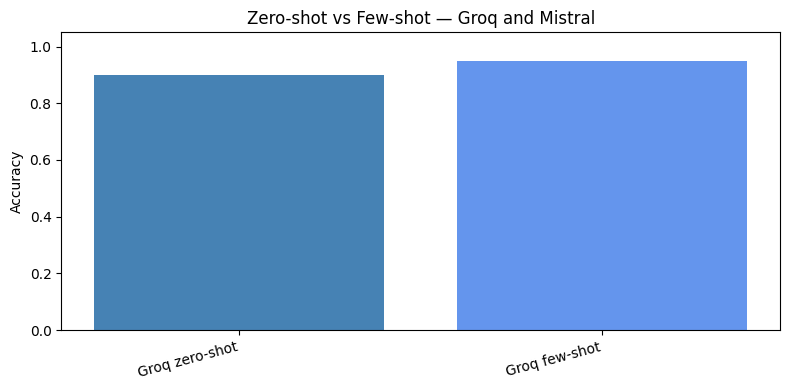

In [20]:
# We need zero-shot predictions on the full test set as well for Groq & Mistral
zs_groq_preds_full, _ = run_experiment(
    test_data, ask_groq, build_zero_shot_prompt
)
zs_mistral_preds_full, _ = run_experiment(
    test_data, ask_mistral, build_zero_shot_prompt
)

results = {
    "Groq zero-shot":    accuracy(zs_groq_preds_full, gold_test),
    "Groq few-shot":     accuracy(fs_groq_preds, gold_test),
    "Mistral zero-shot": accuracy(zs_mistral_preds_full, gold_test),
    "Mistral few-shot":  accuracy(fs_mistral_preds, gold_test),
}

results_df = pd.DataFrame.from_dict(
    results, orient="index", columns=["Accuracy"]
).reset_index().rename(columns={"index": "Setting"})

display(results_df)

# Bar plot of the four accuracies
plt.figure(figsize=(8, 4))
plt.bar(results_df["Setting"], results_df["Accuracy"], color=["steelblue", "cornflowerblue", "tomato", "salmon"])
plt.ylim(0, 1.05)
plt.ylabel("Accuracy")
plt.title("Zero-shot vs Few-shot — Groq and Mistral")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()


## 8. Reflection questions

Answer briefly in your own words.

1. **Did few-shot improve performance?**  
   Generally yes — providing one labeled example per class helps the model understand the expected output format and category boundaries, usually increasing accuracy compared to zero-shot.

2. **Which classes seemed easiest or hardest?**  
   *Sports* and *World* tend to be easiest because they have distinctive vocabulary. *Business* vs *Sci/Tech* can be harder when articles overlap (e.g., tech company earnings reports).

3. **Were the outputs always clean and easy to parse?**  
   Not always. Models sometimes add punctuation, explanations, or extra words. The `normalize_prediction` function handles most cases via substring search, but occasional failures still occur.

4. **How sensitive were the results to prompt wording?**  
   Quite sensitive. Changing the instruction phrasing, the order of the labels, or the support examples can shift accuracy noticeably, even on a small test set.

5. **What are the limitations of API-based prompting for classification?**  
   - Cost and latency per example scale linearly.
   - Non-deterministic outputs even at temperature=0.
   - Rate limits restrict throughput.
   - No control over the model's internal representations.
   - Output parsing can fail.

6. **When would you prefer a supervised classifier instead?**  
   When labeled data is plentiful, when inference cost matters (serving millions of examples), when latency requirements are strict, or when the task requires fine-grained domain-specific categories that a general LLM may not handle well.

## 9. Optional extensions

Choose one or more:

- Try **2 support examples per class**
- Compare **headline only** vs **full text**
- Force the model to output a **JSON object**
- Build a **confusion matrix**
- Measure **latency** per API
- Estimate **cost / quota usage**
- Intentionally use **biased support examples** and observe what changes

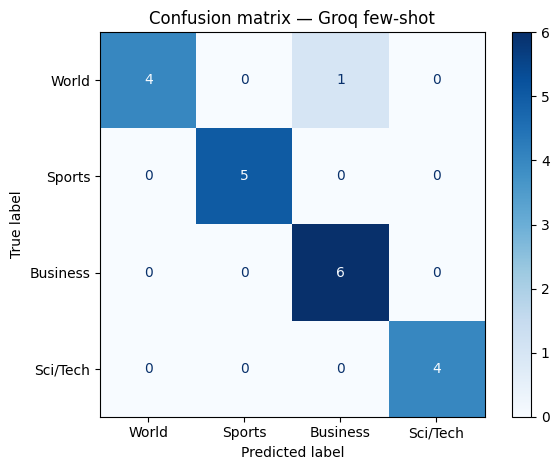

In [21]:
# Optional: Confusion matrix for Groq few-shot
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

gold_names = [LABELS[g] for g in gold_test]
label_order = list(LABELS.values())

# Replace None predictions with a placeholder so sklearn doesn't crash
fs_groq_clean = [p if p is not None else "Unknown" for p in fs_groq_preds]

cm = confusion_matrix(gold_names, fs_groq_clean, labels=label_order)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_order)
disp.plot(cmap="Blues")
plt.title("Confusion matrix — Groq few-shot")
plt.tight_layout()
plt.show()